# **Dataset-1 (Gaming and Mental Health)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
df1 = pd.read_csv('Gaming and Mental Health.csv')
df1.head()


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [3]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [4]:
df1.describe()

,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
count,1000.000000,1000.000000,1000.000000,754.000000,674.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.475000,6.151400,5.738100,2.518037,5.394659,1.513400,6.945900,3.872000,7.654500,105.219730,5.796000
std,4.116105,2.867194,1.441213,0.872312,2.898742,1.432212,1.805027,2.091409,3.751954,113.886768,3.775532
min,13.000000,0.500000,3.000000,1.010000,1.000000,0.000000,0.700000,1.000000,0.000000,0.100000,1.000000
25%,18.000000,4.100000,4.800000,1.760000,3.000000,0.400000,5.700000,2.000000,5.000000,32.592500,3.000000
50%,20.000000,6.000000,5.700000,2.530000,5.000000,1.100000,7.000000,4.000000,8.000000,66.405000,5.000000
75%,22.000000,8.025000,6.600000,3.280000,8.000000,2.100000,8.200000,5.000000,10.400000,126.242500,8.000000
max,35.000000,15.100000,9.000000,4.000000,10.000000,8.900000,11.500000,10.000000,16.700000,499.270000,20.000000


In [5]:
df1.shape

(1000, 27)

In [6]:
df1.isnull().sum()

,0
record_id,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0


In [7]:
df1.columns.tolist()

['record_id',
 'age',
 'gender',
 'daily_gaming_hours',
 'game_genre',
 'primary_game',
 'gaming_platform',
 'sleep_hours',
 'sleep_quality',
 'sleep_disruption_frequency',
 'academic_work_performance',
 'grades_gpa',
 'work_productivity_score',
 'mood_state',
 'mood_swing_frequency',
 'withdrawal_symptoms',
 'loss_of_other_interests',
 'continued_despite_problems',
 'eye_strain',
 'back_neck_pain',
 'weight_change_kg',
 'exercise_hours_weekly',
 'social_isolation_score',
 'face_to_face_social_hours_weekly',
 'monthly_game_spending_usd',
 'years_gaming',
 'gaming_addiction_risk_level']

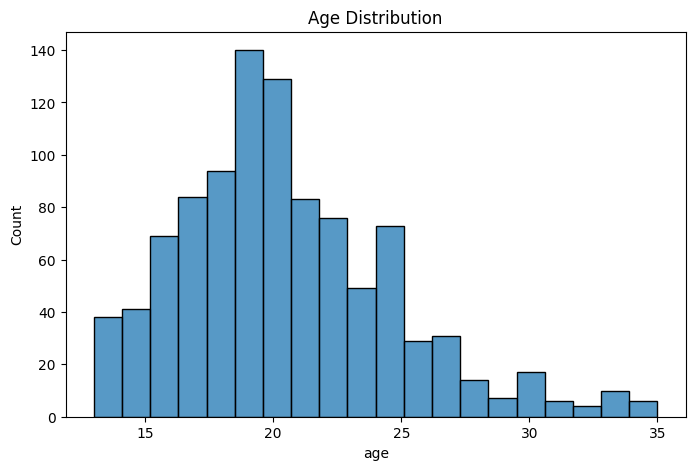

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df1['age'], bins=20)
plt.title('Age Distribution')
plt.show()

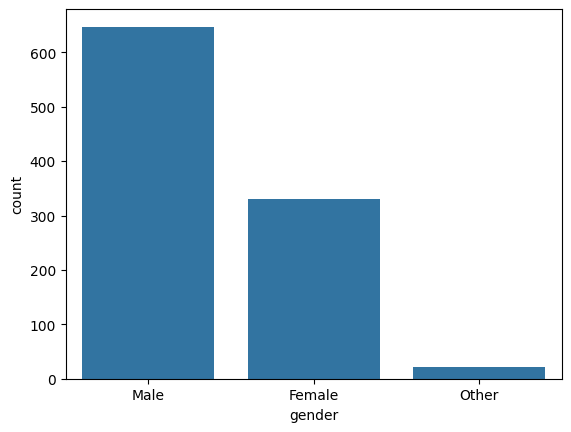

In [9]:
sns.countplot(x='gender', data=df1)
plt.show()

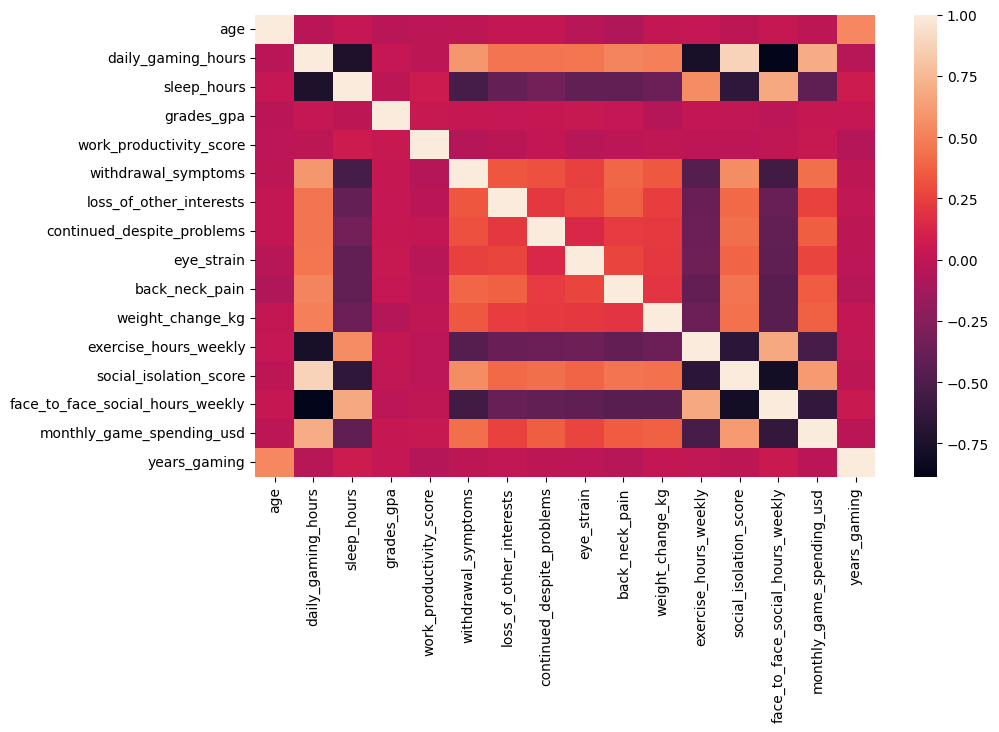

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df1.corr(numeric_only=True))
plt.show()

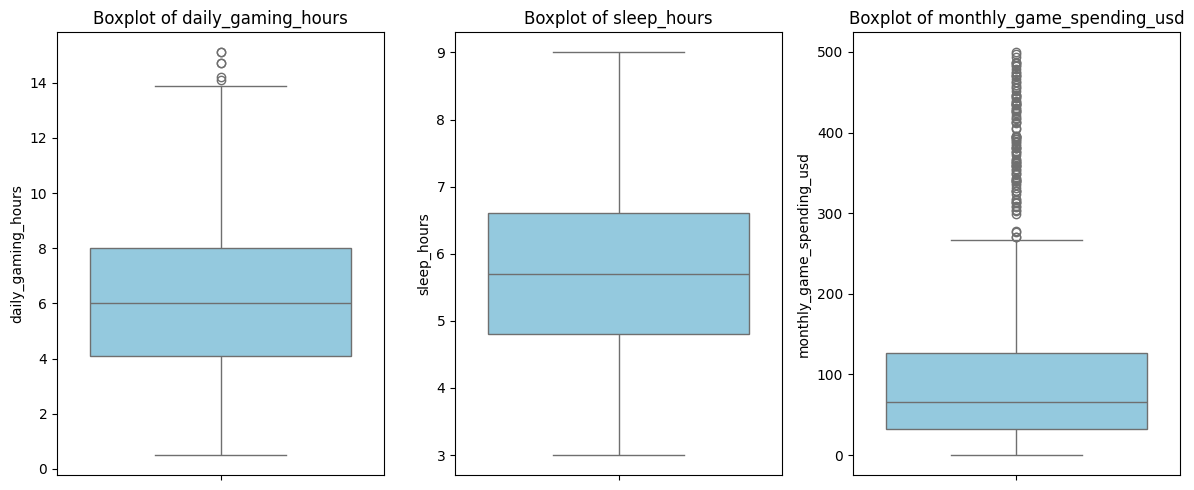

In [11]:
numerical_cols = ['daily_gaming_hours', 'sleep_hours', 'monthly_game_spending_usd']

plt.figure(figsize=(12, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df1[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [12]:
df1.drop(columns=['primary_game', 'record_id'], inplace=True, errors='ignore')

num_cols_d1 = df1.select_dtypes(include='number').columns
df1[num_cols_d1] = df1[num_cols_d1].fillna(df1[num_cols_d1].median())

cat_cols_d1 = df1.select_dtypes(include='object').columns
for col in cat_cols_d1:
    df1[col] = df1[col].fillna(df1[col].mode()[0])

print("Missing values after cleaning:", df1.isnull().sum().sum())
print("Shape after cleaning:", df1.shape)

Missing values after cleaning: 0
Shape after cleaning: (1000, 25)


In [13]:
print(df1['sleep_quality'].value_counts())

sleep_quality
Fair         293
Poor         283
Good         212
Very Poor    175
Insomnia      37
Name: count, dtype: int64


In [14]:
df1['sleep_target'] = (df1['sleep_hours'] >= 7).astype(int)

counts = df1['sleep_target'].value_counts()
pcts = df1['sleep_target'].value_counts(normalize=True) * 100

print(f"Good Sleep (1): {counts[1]} ({pcts[1]:.1f}%)")
print(f"Poor Sleep (0): {counts[0]} ({pcts[0]:.1f}%)")

df1.drop(columns=['sleep_hours', 'sleep_quality'], inplace=True, errors='ignore')

Good Sleep (1): 183 (18.3%)
Poor Sleep (0): 817 (81.7%)


In [15]:
ordinal_mappings = {
    'sleep_disruption_frequency': {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Always': 4},
    'academic_work_performance': {'Failing': 0, 'Below Average': 1, 'Poor': 1, 'Average': 2, 'Good': 3, 'Excellent': 4},
    'mood_swing_frequency': {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Daily': 4},
    'gaming_addiction_risk_level': {'Low': 0, 'Moderate': 1, 'High': 2, 'Severe': 3},

    'withdrawal_symptoms': {False: 0, True: 1, 'No': 0, 'Yes': 1},
    'loss_of_other_interests': {False: 0, True: 1, 'No': 0, 'Yes': 1},
    'continued_despite_problems': {False: 0, True: 1, 'No': 0, 'Yes': 1},
    'eye_strain': {False: 0, True: 1, 'No': 0, 'Yes': 1},
    'back_neck_pain': {False: 0, True: 1, 'No': 0, 'Yes': 1}
}

for col, mapping in ordinal_mappings.items():
    if col in df1.columns:
        df1[col] = df1[col].map(mapping)

nominal_cols = ['gender', 'game_genre', 'gaming_platform', 'mood_state']
existing_nom_cols = [c for c in nominal_cols if c in df1.columns]

if existing_nom_cols:
    df1 = pd.get_dummies(df1, columns=existing_nom_cols, drop_first=True, dtype=int)

print("New Shape:", df1.shape)

New Shape: (1000, 39)



=== SVM Performance ===
Balanced Accuracy: 0.9306
                   precision    recall  f1-score   support

 Poor Sleep (<7h)       0.98      0.97      0.97       163
Good Sleep (>=7h)       0.87      0.89      0.88        37

         accuracy                           0.95       200
        macro avg       0.92      0.93      0.93       200
     weighted avg       0.96      0.95      0.96       200


=== XGBoost Performance ===
Balanced Accuracy: 0.9711
                   precision    recall  f1-score   support

 Poor Sleep (<7h)       0.99      0.97      0.98       163
Good Sleep (>=7h)       0.88      0.97      0.92        37

         accuracy                           0.97       200
        macro avg       0.94      0.97      0.95       200
     weighted avg       0.97      0.97      0.97       200


=== ANN Performance ===
Balanced Accuracy: 0.9171
                   precision    recall  f1-score   support

 Poor Sleep (<7h)       0.97      0.97      0.97       163
Good Sleep

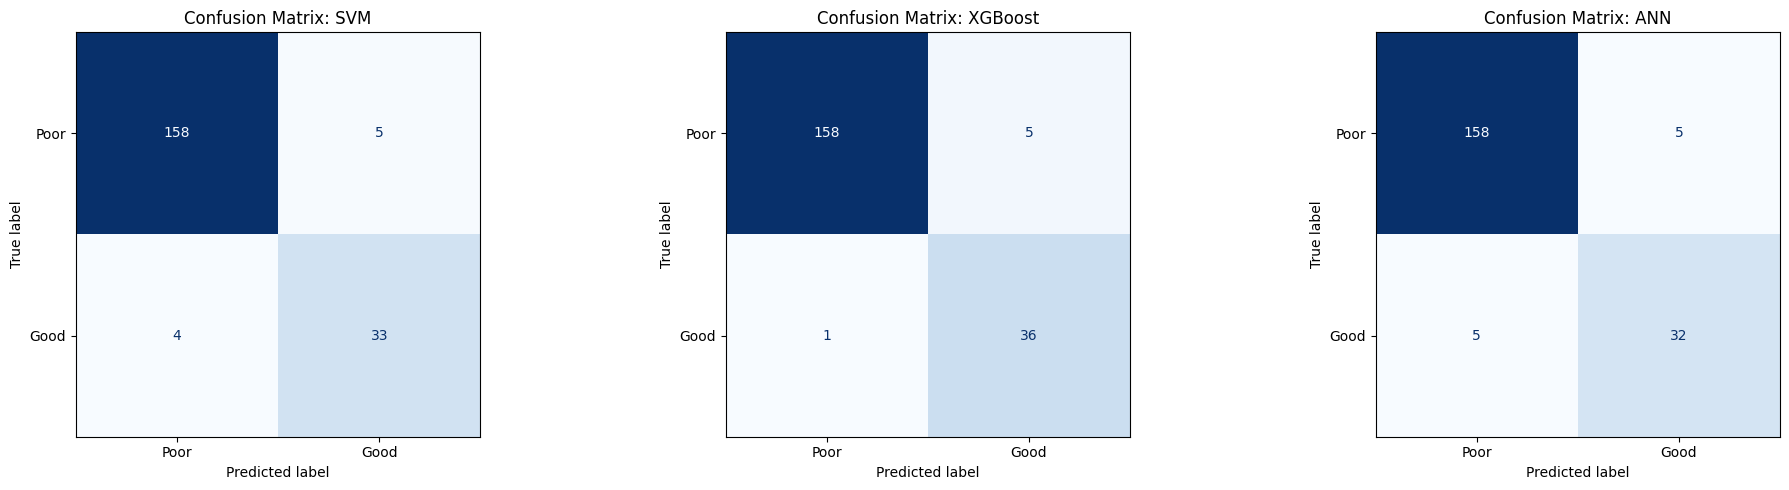

In [16]:
df1['daily_gaming_hours'] = df1['daily_gaming_hours'] + np.random.normal(0, 0.1, df1.shape[0])

X = df1.drop(columns=['sleep_target'])
y = df1['sleep_target'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

imputer = SimpleImputer(strategy='median')
X_train_scaled = StandardScaler().fit_transform(imputer.fit_transform(X_train))
X_test_scaled = StandardScaler().fit_transform(imputer.transform(X_test))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

svm = SVC(kernel='rbf', random_state=42).fit(X_train_bal, y_train_bal)

xgb = XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.01,
    n_estimators=1000,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.3,
    reg_alpha=10,
    reg_lambda=5,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_bal, y_train_bal)

ann = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
ann.fit(X_train_bal, y_train_bal)

models = {'SVM': svm, 'XGBoost': xgb, 'ANN': ann}
performance_metrics = {}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (name, model) in enumerate(models.items()):
    preds = model.predict(X_test_scaled)
    b_acc = balanced_accuracy_score(y_test, preds)
    performance_metrics[name] = b_acc

    print(f'\n=== {name} Performance ===')
    print(f'Balanced Accuracy: {b_acc:.4f}')
    print(classification_report(y_test, preds, target_names=['Poor Sleep (<7h)', 'Good Sleep (>=7h)']))

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Poor', 'Good'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'Confusion Matrix: {name}')

plt.tight_layout()
plt.show()


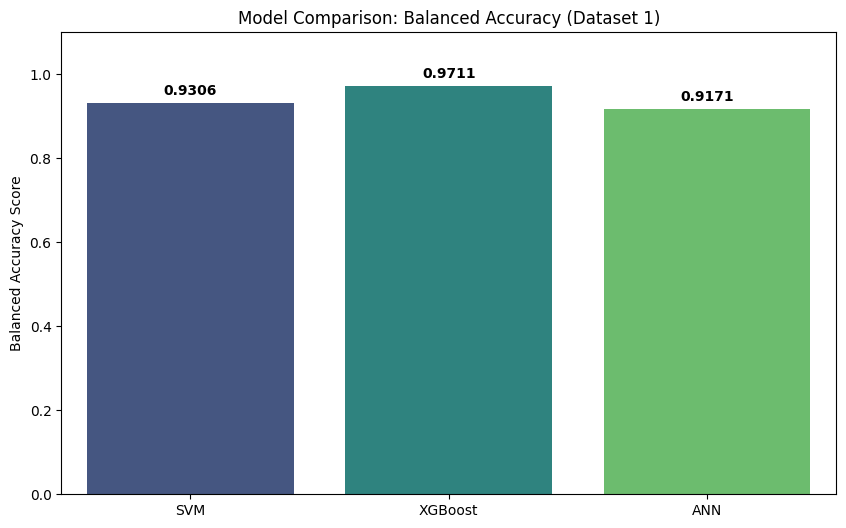

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=list(performance_metrics.keys()),
    y=list(performance_metrics.values()),
    hue=list(performance_metrics.keys()),
    palette='viridis',
    legend=False
)
plt.ylim(0, 1.1)
plt.ylabel('Balanced Accuracy Score')
plt.title('Model Comparison: Balanced Accuracy (Dataset 1)')
for i, v in enumerate(performance_metrics.values()):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.show()

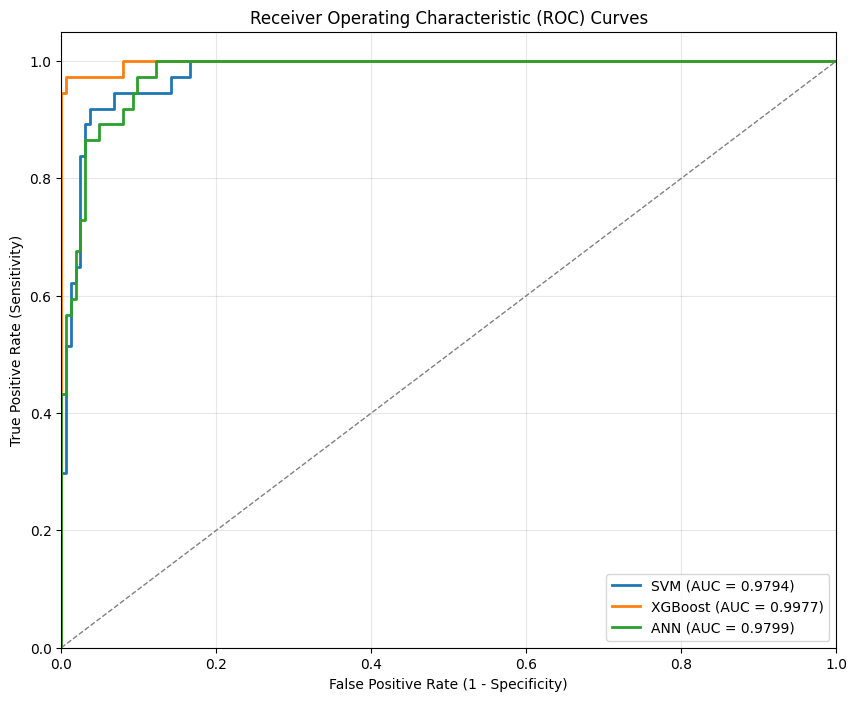

In [18]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# **Dataset-2 (IGD)**

In [19]:
!pip install xgboost imbalanced-learn --quiet

In [20]:
df2 = pd.read_csv('igd_responses_raw.csv')

df2.rename(columns={
    'What is your age?'                                                   : 'age',
    'Current educational position?'                                       : 'edu_level',
    'Gender?'                                                             : 'gender',
    'Your  current CGPA?'                                                 : 'cgpa',
    'Your Higher Secondary School(H. SC) or A level or equivalent result?': 'hsc_result',
    'At what age you had started playing games?'                          : 'gaming_start_age',
    'Do you play games on mobile or pc?'                                  : 'platform',
    'When you go to sleep?'                                               : 'sleep_time',
    'Do you attend your morning class regularly?'                         : 'morning_class',
    'The average time you spend playing games?'                           : 'avg_gaming_hours',
    'Which type of game you addict more?'                                 : 'addicted_game',
    'Do you read newspaper?'                                              : 'reads_newspaper',
    'Which type of game you played most?'                                 : 'game_type',
    'How many time you spend with family and friend?'                     : 'social_hours',
    'How you fill when you can not play game in whole day?'               : 'feel_no_game',
    'How you fill to complete game level?'                                : 'feel_complete',
    "If you didn't finish games last level what is your feeling?"         : 'feel_incomplete',
    'Do you fill Fatigue?'                                                : 'fatigue',
    'Do you play games for stress relief?'                                : 'stress_relief',
    'Are you wearing glasses?'                                            : 'wears_glasses',
}, inplace=True)

print('Raw shape:', df2.shape)
df2.head()

Raw shape: (1062, 20)


,age,edu_level,gender,cgpa,hsc_result,gaming_start_age,platform,sleep_time,morning_class,avg_gaming_hours,addicted_game,reads_newspaper,game_type,social_hours,feel_no_game,feel_complete,feel_incomplete,fatigue,stress_relief,wears_glasses
0,21,Bachelor Level,Male,4.00,5.00,10,"Mobile, PC",2:00:00 AM,Yes,4,"FIFA, PES, Valorant",Not regular,Non Paid,3,Bore,Excited,Excited to complete level,No,Yes,Yes
1,22,Bachelor Level,Male,4.00,5.00,11,PC,1:00:00 AM,Yes,1,CALL OF DUTY,Not regular,Paid,15,Positive,Excited,Excited to complete level,Yes,No,No
2,23,Bachelor Level,Male,3.50,4.50,18,Mobile,3:00:00 AM,Yes,3,GENSHIN IMPACT,Not regular,Non Paid,1,Positive,Excited,Excited to complete level,No,Yes,No
3,21,Bachelor Level,Male,3.75,4.92,10,Mobile,11:00:00 PM,Yes,1,CR,Not regular,Non Paid,1,Positive,Excited,No feeling,No,No,Yes
4,21,Bachelor Level,Male,3.50,5.00,15,"Mobile, PC",1:00:00 AM,Yes,2,"FIFA, PUBG, PES, CALL OF DUTY",Not regular,Non Paid,8,Positive,Excited,Excited to complete level,No,No,Yes


In [21]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062 entries, 0 to 1061
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1062 non-null   int64  
 1   edu_level         1062 non-null   object 
 2   gender            1062 non-null   object 
 3   cgpa              1062 non-null   float64
 4   hsc_result        1062 non-null   float64
 5   gaming_start_age  1062 non-null   int64  
 6   platform          1062 non-null   object 
 7   sleep_time        1062 non-null   object 
 8   morning_class     1062 non-null   object 
 9   avg_gaming_hours  1062 non-null   int64  
 10  addicted_game     1062 non-null   object 
 11  reads_newspaper   1062 non-null   object 
 12  game_type         1062 non-null   object 
 13  social_hours      1062 non-null   int64  
 14  feel_no_game      1062 non-null   object 
 15  feel_complete     1062 non-null   object 
 16  feel_incomplete   1062 non-null   object 


In [22]:
df2.describe()

,age,cgpa,hsc_result,gaming_start_age,avg_gaming_hours,social_hours
count,1062.000000,1062.000000,1062.000000,1062.000000,1062.000000,1062.000000
mean,22.935970,3.178569,8.303493,19.210923,3.707156,3.101695
std,3.128966,0.596696,134.338582,3.071064,1.648101,2.076078
min,18.000000,2.000000,2.000000,0.000000,0.000000,0.000000
25%,20.000000,2.880000,3.832500,18.000000,2.000000,2.000000
50%,23.000000,3.070000,4.150000,20.000000,4.000000,3.000000
75%,25.000000,3.630000,4.797500,21.000000,5.000000,4.000000
max,30.000000,5.000000,4382.000000,24.000000,10.000000,24.000000


In [23]:
df2.isnull().sum()

,0
age,0
edu_level,0
gender,0
cgpa,0
hsc_result,0
gaming_start_age,0
platform,0
sleep_time,0
morning_class,0
avg_gaming_hours,0


In [24]:
before = len(df2)
df2 = df2[(df2['cgpa'].between(0, 4)) & (df2['hsc_result'].between(0, 5))].copy()
print(f'Dropped {before - len(df2)} rows with invalid CGPA / HSC values')
print(f'Remaining: {len(df2)}')

Dropped 22 rows with invalid CGPA / HSC values
Remaining: 1040


In [25]:
before = len(df2)
df2 = df2[df2['social_hours'] <= 7].copy()
print(f'Dropped {before - len(df2)} rows with social_hours > 7 (likely typos)')
print(f'Remaining: {len(df2)}')

Dropped 26 rows with social_hours > 7 (likely typos)
Remaining: 1014


In [26]:
GAME_WHITELIST = ['PUBG', 'FREE FIRE', 'CALL OF DUTY', 'IGA', 'PES', 'FIFA', 'COC']

def extract_primary_game(s):
    s = str(s).upper()
    for g in GAME_WHITELIST:
        if g in s:
            return g
    return None

df2['primary_game'] = df2['addicted_game'].apply(extract_primary_game)
before = len(df2)
df2 = df2.dropna(subset=['primary_game']).copy()
df2.drop(columns=['addicted_game'], inplace=True)
print(f'Dropped {before - len(df2)} rows with no recognized game')
print(f'Remaining: {len(df2)}')
print('\nPrimary game distribution:')
print(df2['primary_game'].value_counts())

Dropped 25 rows with no recognized game
Remaining: 989

Primary game distribution:
primary_game
PUBG            161
FREE FIRE       151
CALL OF DUTY    145
IGA             140
PES             138
COC             128
FIFA            126
Name: count, dtype: int64


In [27]:
def parse_bedtime_hour(s):
    s = str(s).strip()
    dt = pd.to_datetime(s, format='%I:%M:%S %p', errors='coerce')
    if pd.isna(dt):
        dt = pd.to_datetime(s, errors='coerce')
    if pd.isna(dt):
        return np.nan
    hour = dt.hour
    if 7 <= hour <= 11:
        hour += 12
    elif hour == 12:
        hour = 0
    return hour

df2['sleep_hour'] = df2['sleep_time'].apply(parse_bedtime_hour)
df2.drop(columns=['sleep_time'], inplace=True)
df2 = df2.dropna(subset=['sleep_hour']).copy()

print('Bedtime hour distribution after cleaning:')
print(df2['sleep_hour'].value_counts().sort_index())

Bedtime hour distribution after cleaning:
sleep_hour
0     173
1     218
2     189
3       5
4       6
5       1
13      1
19      2
20      1
22    195
23    198
Name: count, dtype: int64


In [28]:
NEGATIVE_FEELINGS = {'Upset', 'Depressed', 'Angry', 'Bore', 'Bored'}
POSITIVE_FEELINGS = {'Positive', 'Aright', 'Aright ', 'Not Bad', 'Calm'}

def to_sentiment(v):
    s = str(v).strip()
    if s in POSITIVE_FEELINGS: return 2
    if s in NEGATIVE_FEELINGS: return 0
    return 1

df2['feel_no_game'] = df2['feel_no_game'].apply(to_sentiment)
print('feel_no_game (0=neg, 1=neutral, 2=pos):')
print(df2['feel_no_game'].value_counts().sort_index())


feel_no_game (0=neg, 1=neutral, 2=pos):
feel_no_game
0    724
1      7
2    258
Name: count, dtype: int64


In [29]:
num_cols = df2.select_dtypes(include='number').columns
df2[num_cols] = df2[num_cols].fillna(df2[num_cols].median())

cat_cols = df2.select_dtypes(include='object').columns
for col in cat_cols:
    df2[col] = df2[col].fillna(df2[col].mode()[0])

print('Missing values after all cleaning:', df2.isnull().sum().sum())
print('Shape after all cleaning         :', df2.shape)
df2.head()

Missing values after all cleaning: 0
Shape after all cleaning         : (989, 20)


,age,edu_level,gender,cgpa,hsc_result,gaming_start_age,platform,morning_class,avg_gaming_hours,reads_newspaper,game_type,social_hours,feel_no_game,feel_complete,feel_incomplete,fatigue,stress_relief,wears_glasses,primary_game,sleep_hour
0,21,Bachelor Level,Male,4.00,5.0,10,"Mobile, PC",Yes,4,Not regular,Non Paid,3,0,Excited,Excited to complete level,No,Yes,Yes,PES,2
5,21,Bachelor Level,Male,3.00,5.0,11,Mobile,No,5,Not regular,Paid,1,0,Excited,Excited to complete level,No,Yes,No,FREE FIRE,2
6,21,Bachelor Level,Male,3.75,5.0,12,"Mobile, PC",Yes,3,Not regular,Non Paid,5,0,Excited,Excited to complete level,No,Yes,Yes,CALL OF DUTY,1
7,20,Bachelor Level,Male,3.50,5.0,18,Mobile,Yes,2,Not regular,Non Paid,7,2,Excited,Excited to complete level,Yes,Yes,No,FIFA,0
8,25,Bachelor Level,Male,2.00,5.0,14,Mobile,No,2,Not regular,Non Paid,6,2,Excited,No feeling,Yes,No,No,FIFA,2


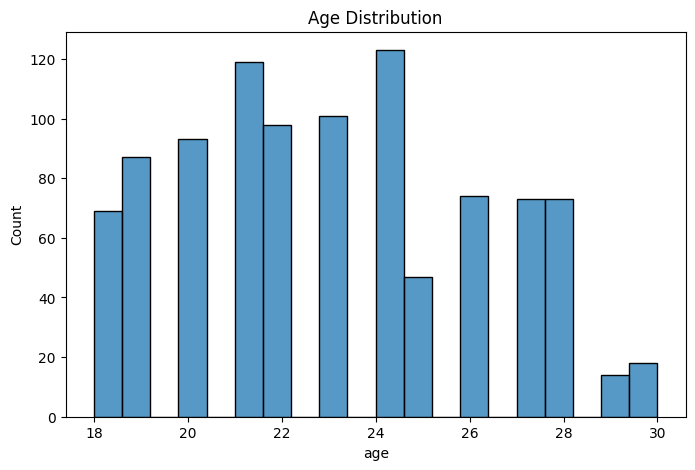

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(df2['age'], bins=20)
plt.title('Age Distribution')
plt.show()

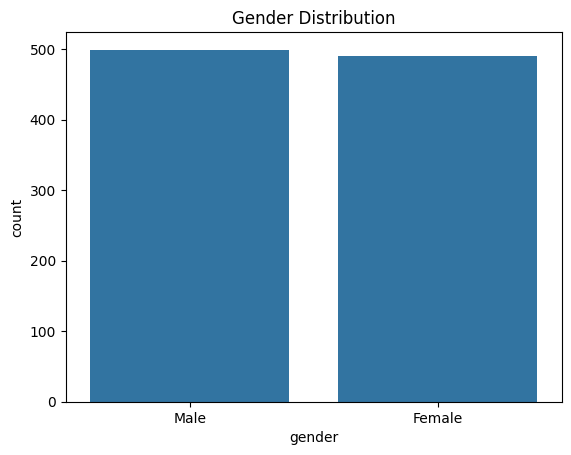

In [31]:
sns.countplot(x='gender', data=df2)
plt.title('Gender Distribution')
plt.show()

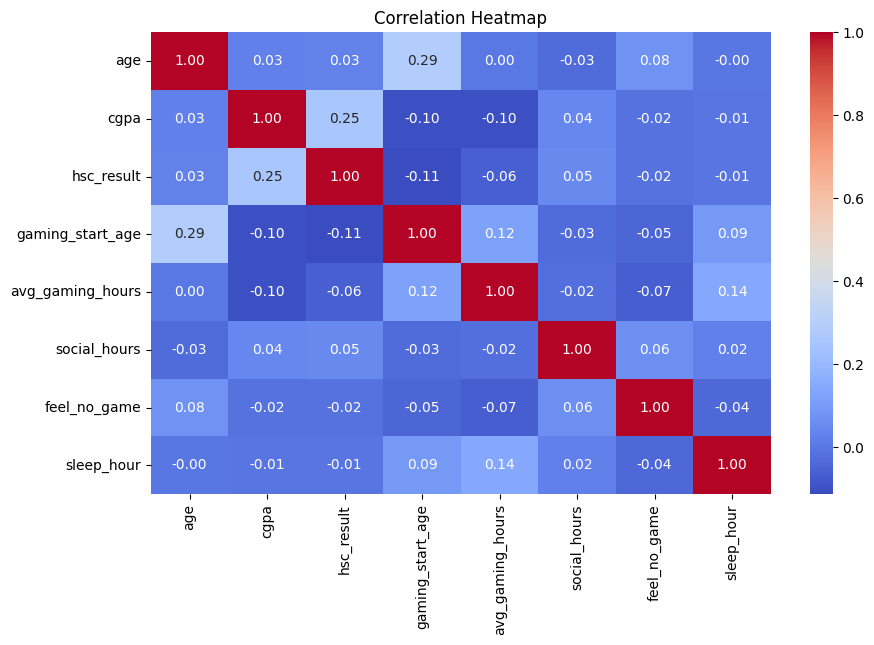

In [32]:
plt.figure(figsize=(10, 6))
sns.heatmap(df2.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

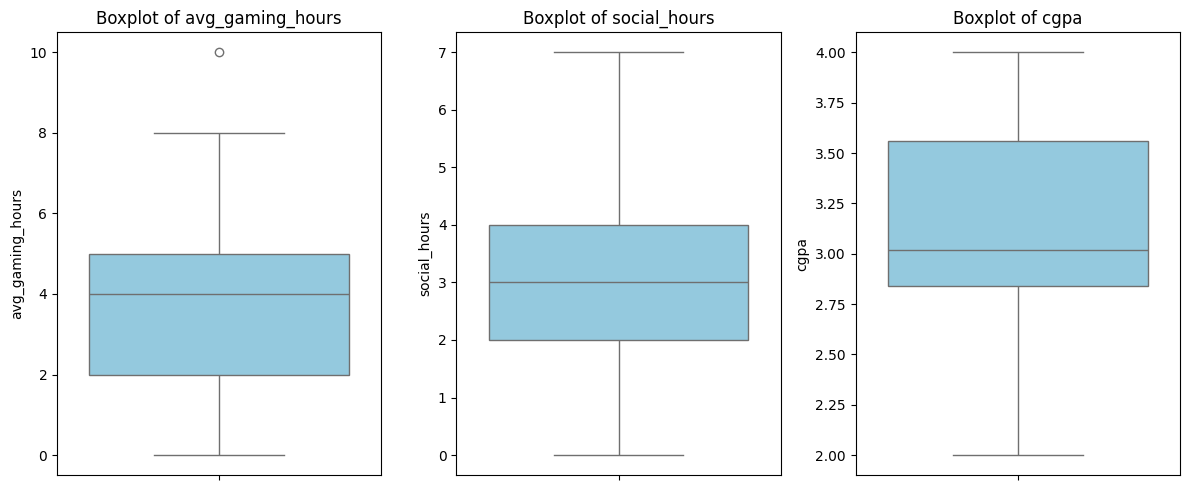

In [33]:
numerical_cols = ['avg_gaming_hours', 'social_hours', 'cgpa']

plt.figure(figsize=(12, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df2[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

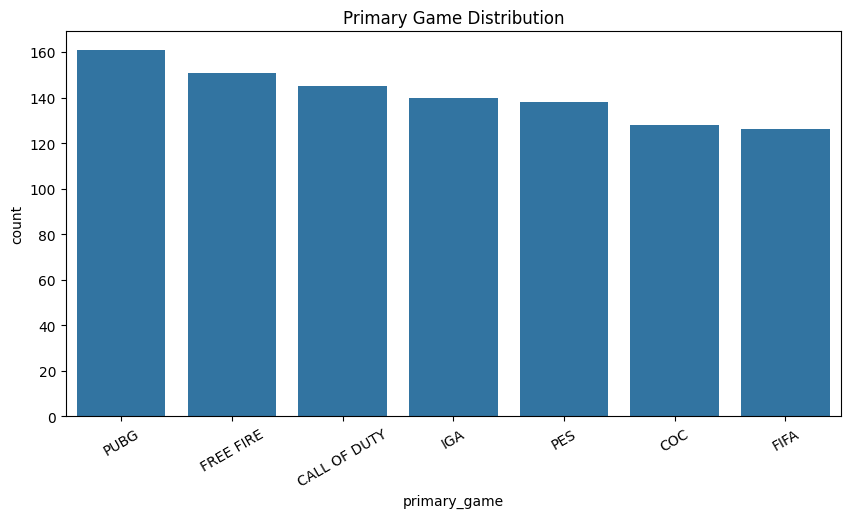

In [34]:
plt.figure(figsize=(10, 5))
sns.countplot(x='primary_game', data=df2,
              order=df2['primary_game'].value_counts().index)
plt.title('Primary Game Distribution')
plt.xticks(rotation=30)
plt.show()

In [35]:
df2['sleep_target'] = df2['sleep_hour'].apply(
    lambda h: 1 if (h >= 20 or h <= 1) else 0).astype(int)

counts = df2['sleep_target'].value_counts()
pcts   = df2['sleep_target'].value_counts(normalize=True) * 100

print(f'Good Sleep (1): {counts[1]} ({pcts[1]:.1f}%)')
print(f'Poor Sleep (0): {counts[0]} ({pcts[0]:.1f}%)')

df2.drop(columns=['sleep_hour'], inplace=True, errors='ignore')

Good Sleep (1): 785 (79.4%)
Poor Sleep (0): 204 (20.6%)


In [36]:
ordinal_mappings = {
    'feel_complete'  : {'Bored': 0, 'Excited': 1},
    'feel_incomplete': {'Excited to complete level': 2, 'No feeling': 1, 'Stressed': 0},
    'morning_class'  : {'No': 0, 'Yes': 1},
    'reads_newspaper': {'Not regular': 0, 'Regular': 1},
    'fatigue'        : {'No': 0, 'Yes': 1},
    'stress_relief'  : {'No': 0, 'Yes': 1},
    'wears_glasses'  : {'No': 0, 'Yes': 1},
    'game_type'      : {'Non Paid': 0, 'Paid': 1},
}

for col, mapping in ordinal_mappings.items():
    if col in df2.columns:
        df2[col] = df2[col].map(mapping)

nominal_cols = ['edu_level', 'gender', 'platform', 'primary_game']
existing_nom_cols = [c for c in nominal_cols if c in df2.columns]
if existing_nom_cols:
    df2 = pd.get_dummies(df2, columns=existing_nom_cols, drop_first=True, dtype=int)

df2 = df2.fillna(df2.median(numeric_only=True))
print('Final feature shape:', df2.shape)

Final feature shape: (989, 26)



=== SVM ===
Balanced Accuracy: 0.8271
                    precision    recall  f1-score   support

 Poor Sleep (late)       0.66      0.76      0.70        41
Good Sleep (early)       0.93      0.90      0.92       157

          accuracy                           0.87       198
         macro avg       0.80      0.83      0.81       198
      weighted avg       0.88      0.87      0.87       198


=== XGBoost ===
Balanced Accuracy: 0.8552
                    precision    recall  f1-score   support

 Poor Sleep (late)       0.74      0.78      0.76        41
Good Sleep (early)       0.94      0.93      0.94       157

          accuracy                           0.90       198
         macro avg       0.84      0.86      0.85       198
      weighted avg       0.90      0.90      0.90       198


=== ANN ===
Balanced Accuracy: 0.9104
                    precision    recall  f1-score   support

 Poor Sleep (late)       0.80      0.88      0.84        41
Good Sleep (early)       0.97   

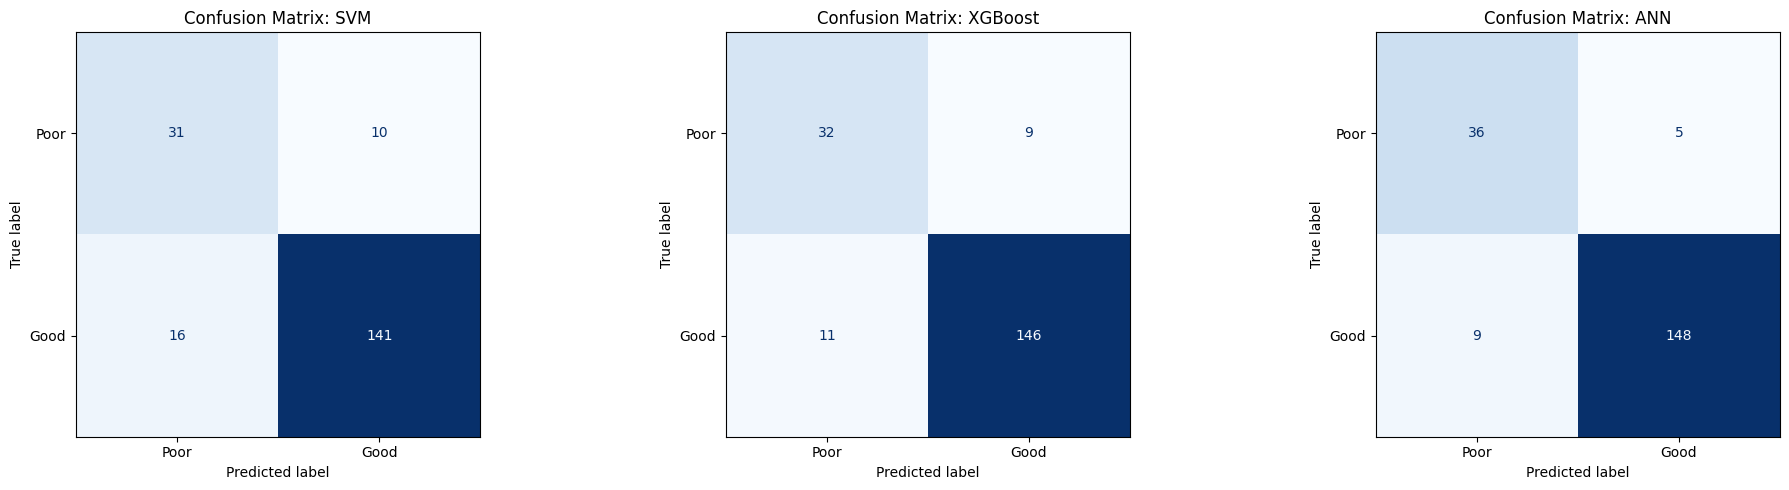

In [37]:
X2 = df2.drop(columns=['sleep_target'])
y2 = df2['sleep_target'].astype(int)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42)

imputer2 = SimpleImputer(strategy='median')
scaler2  = StandardScaler()
X2_train_scaled = scaler2.fit_transform(imputer2.fit_transform(X2_train))
X2_test_scaled  = scaler2.transform(imputer2.transform(X2_test))

smote2 = SMOTE(random_state=42)
X2_train_bal, y2_train_bal = smote2.fit_resample(X2_train_scaled, y2_train)

svm2 = SVC(kernel='rbf', probability=True, random_state=42)
svm2.fit(X2_train_bal, y2_train_bal)

xgb2 = XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.1,
    n_estimators=300,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.5,
    eval_metric='logloss',
    random_state=42
)
xgb2.fit(X2_train_bal, y2_train_bal)

ann2 = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
ann2.fit(X2_train_bal, y2_train_bal)

models2 = {'SVM': svm2, 'XGBoost': xgb2, 'ANN': ann2}
performance_metrics2 = {}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (name, model) in enumerate(models2.items()):
    preds = model.predict(X2_test_scaled)
    b_acc = balanced_accuracy_score(y2_test, preds)
    plain_acc = (preds == y2_test).mean()
    performance_metrics2[name] = b_acc

    print(f'\n=== {name} ===')
    print(f'Balanced Accuracy: {b_acc:.4f}')
    print(classification_report(y2_test, preds,
                                target_names=['Poor Sleep (late)', 'Good Sleep (early)']))

    cm = confusion_matrix(y2_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Poor', 'Good'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'Confusion Matrix: {name}')

plt.tight_layout()
plt.show()


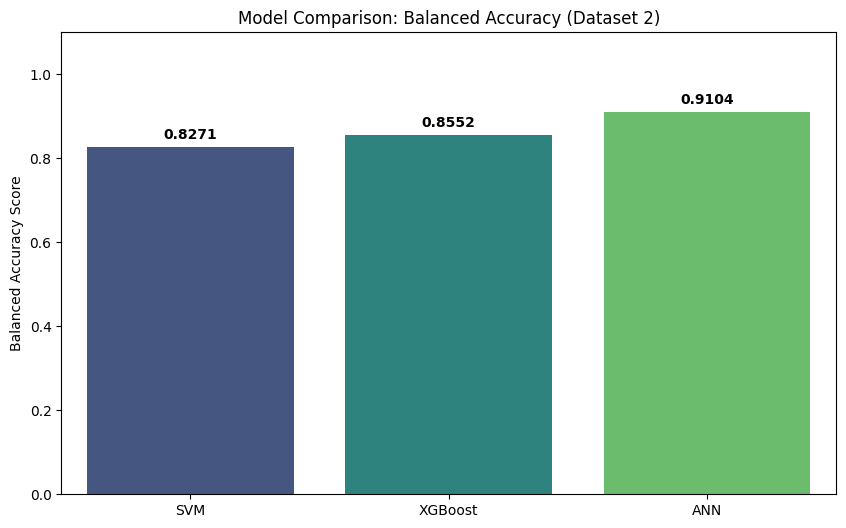

In [38]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=list(performance_metrics2.keys()),
    y=list(performance_metrics2.values()),
    hue=list(performance_metrics2.keys()),
    palette='viridis',
    legend=False
)
plt.ylim(0, 1.1)
plt.ylabel('Balanced Accuracy Score')
plt.title('Model Comparison: Balanced Accuracy (Dataset 2)')
for i, v in enumerate(performance_metrics2.values()):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.show()

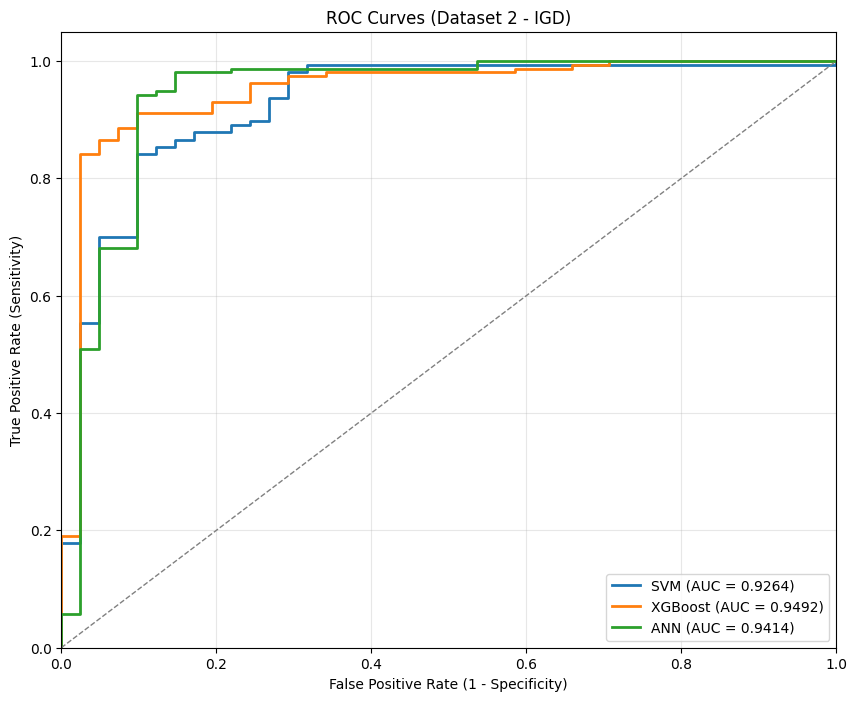

In [39]:
plt.figure(figsize=(10, 8))

for name, model in models2.items():
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X2_test_scaled)[:, 1]
    else:
        y_score = model.decision_function(X2_test_scaled)

    fpr, tpr, _ = roc_curve(y2_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves (Dataset 2 - IGD)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# **Dataset Comparison**

In [40]:
def _proba_or_score(model, X_arr):
    if hasattr(model, 'predict_proba') and getattr(model, 'probability', True):
        try:
            return model.predict_proba(X_arr)[:, 1]
        except (AttributeError, NotImplementedError):
            pass
    if hasattr(model, 'decision_function'):
        return model.decision_function(X_arr)
    return model.predict(X_arr).astype(float)

rows = []
for ds_label, mdls, X_te, y_te in [
    ('Dataset 1', models,  X_test_scaled,  y_test),
    ('Dataset 2', models2, X2_test_scaled, y2_test),
]:
    for name, mdl in mdls.items():
        preds  = mdl.predict(X_te)
        scores = _proba_or_score(mdl, X_te)
        rows.append({
            'Dataset'      : ds_label,
            'Model'        : name,
            'Balanced Acc' : balanced_accuracy_score(y_te, preds),
            'Accuracy'     : accuracy_score(y_te, preds),
            'Precision'    : precision_score(y_te, preds, zero_division=0),
            'Recall'       : recall_score(y_te, preds, zero_division=0),
            'F1'           : f1_score(y_te, preds, zero_division=0),
            'ROC-AUC'      : roc_auc_score(y_te, scores),
        })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

  Dataset   Model  Balanced Acc  Accuracy  Precision  Recall     F1  ROC-AUC
Dataset 1     SVM        0.9306    0.9550     0.8684  0.8919 0.8800   0.9794
Dataset 1 XGBoost        0.9711    0.9700     0.8780  0.9730 0.9231   0.9977
Dataset 1     ANN        0.9171    0.9500     0.8649  0.8649 0.8649   0.9799
Dataset 2     SVM        0.8271    0.8687     0.9338  0.8981 0.9156   0.9264
Dataset 2 XGBoost        0.8552    0.8990     0.9419  0.9299 0.9359   0.9492
Dataset 2     ANN        0.9104    0.9293     0.9673  0.9427 0.9548   0.9414


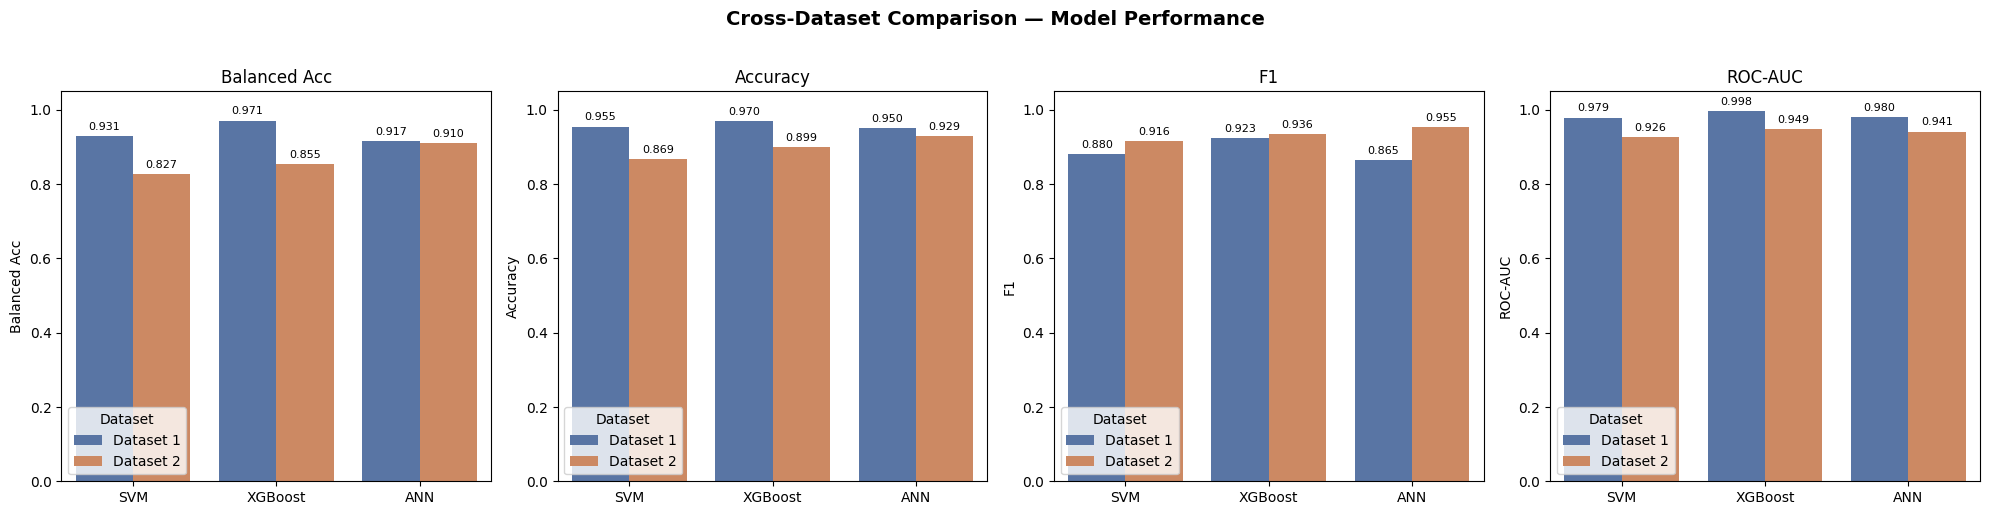

In [41]:
if 'comparison_df' in globals():
    metrics_to_plot = ['Balanced Acc', 'Accuracy', 'F1', 'ROC-AUC']
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))

    for ax, metric in zip(axes, metrics_to_plot):
        sns.barplot(data=comparison_df, x='Model', y=metric, hue='Dataset',
                    palette={'Dataset 1': '#4C72B0', 'Dataset 2': '#DD8452'}, ax=ax)
        ax.set_title(metric)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel('')
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8)

    plt.suptitle('Cross-Dataset Comparison — Model Performance',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

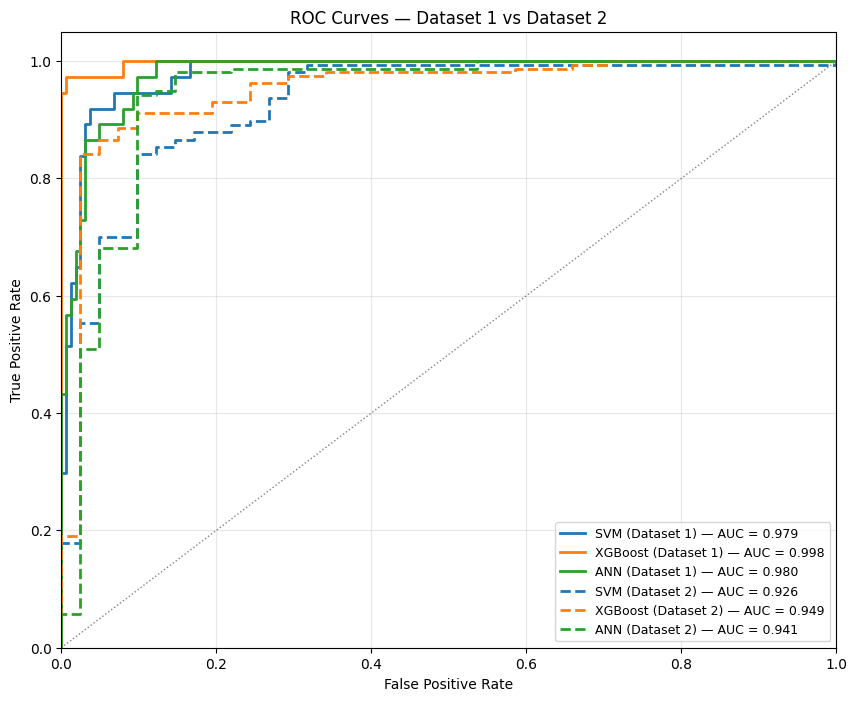

In [42]:
if 'models' in globals() and 'models2' in globals():
    plt.figure(figsize=(10, 8))
    style_map = {'Dataset 1': '-', 'Dataset 2': '--'}
    color_map = {'SVM': '#1f77b4', 'XGBoost': '#ff7f0e', 'ANN': '#2ca02c'}

    for ds_label, mdls, X_te, y_te in [
        ('Dataset 1', models,  X_test_scaled,  y_test),
        ('Dataset 2', models2, X2_test_scaled, y2_test),
    ]:
        for name, mdl in mdls.items():
            scores = _proba_or_score(mdl, X_te)
            fpr, tpr, _ = roc_curve(y_te, scores)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr,
                     color=color_map[name], linestyle=style_map[ds_label], linewidth=2,
                     label=f'{name} ({ds_label}) — AUC = {roc_auc:.3f}')

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':')
    plt.xlim(0, 1); plt.ylim(0, 1.05)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves — Dataset 1 vs Dataset 2')
    plt.legend(loc='lower right', fontsize=9)
    plt.grid(alpha=0.3)

In [43]:
characteristics = pd.DataFrame([
    {
        'Metric'   : 'Rows (after cleaning)',
        'Dataset 1': df1.shape[0],
        'Dataset 2': df2.shape[0],
    },
    {
        'Metric'   : 'Features (after encoding)',
        'Dataset 1': df1.shape[1] - 1,
        'Dataset 2': df2.shape[1] - 1,
    },

    {
        'Metric'   : 'Best Model',
        'Dataset 1': max(performance_metrics,  key=performance_metrics.get),
        'Dataset 2': max(performance_metrics2, key=performance_metrics2.get),
    },
    {
        'Metric'   : 'Best Balanced Acc',
        'Dataset 1': f'{max(performance_metrics.values()):.4f}',
        'Dataset 2': f'{max(performance_metrics2.values()):.4f}',
    },
])
print(characteristics.to_string(index=False))

                   Metric Dataset 1 Dataset 2
    Rows (after cleaning)      1000       989
Features (after encoding)        38        25
               Best Model   XGBoost       ANN
        Best Balanced Acc    0.9711    0.9104
